<a href="https://colab.research.google.com/github/Albedofan69420/FASHION-MNIST/blob/main/MLP_Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integrantes:


* Soledad Faundez Labra,

* Esteban Olivares Cabrera,

* Martin Osorio Martinez,

* Renato Espina Cid,

* Carlo Reyes Espinoza,

* Ignacia Reyes Espinoza.

**Asignatura:**
* Deep Learning.

**Docente:**
* Marcelo Tapia Contreras.
---

---


# **Introducción:**


En el presente trabajo se aplicarán los fundamentos de Deep Learning mediante la implementación de una red neuroal artificial de tipo *Multilayer Perceptron (MLP)* para resolver un problema de clasificación de imágenes. Para ello, se utiliza el data set **Fashion-MNIST**, el cual contiene imágenes en escala de grises de 28x28 píxeles correspondientes a distintas categorías de prendas de vestir, tales como camisetas, pantalones, zapatillas, entre otros.



**Objetivo principal:**

Desarrollar un modelo capaz de aprender patrones a partir de los datos y clasificar correctamente nuevas imágenes. Para lograrlo, se realiza un proceso completo que abarca desde la carga y preprocesamiento de los datos hasta la evaluación del modelo utilziando diversas métricas de desempeño.

En una primera etapa, se preparan los datos para su uso en redes neuroales, transformando las imágenes a vectores y normalizando sus valores para mejorar la eficiencia del entrenamiento. Posteriormente, se construye una red neuronal multicapa, definiendo su arquitectura, funciones de activación y función de pérdida.

A continuación, se entrenará el modelo variando distintos hiperparámetros claves, tales como el número de épocas, tamaño de batch y optimizadores. Se realizará una comparación entre distintos algoritmos de optimización, incluyendo *SGD, Adam, RMSprop*, así como variantes como *Momentum y Nesterov*, con el fin de identificar cuál ofrece un mejor desempeño.

Además, se incorporarán técnicas de regularización como *Dropout y Early Stopping*, con el objetivo de reducir el sobreajuste(*overfitting*) y mejorar la capacidad de generalización del modelo.

Finalmente, el desempeño del modelo será evaluado mediante métricas como *accuracy, precision, recall y F1-score*, permitiendo analizar de manera integral la calidad de las predicciones. A partir de estos resultados, se jusatificarán las decisiones tomadas durante el desarrollo y se seleccionará la mejor configuración del modelo, mostrando ejemplos visuales de cómo responde el mejor modelo obtenido.



---
---


# **PARTE 1: Carga de Datos.**

In [ ]:
# import de librerias
from tensorflow import keras
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# Semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Cargar dataset Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Mostrar dimensiones
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


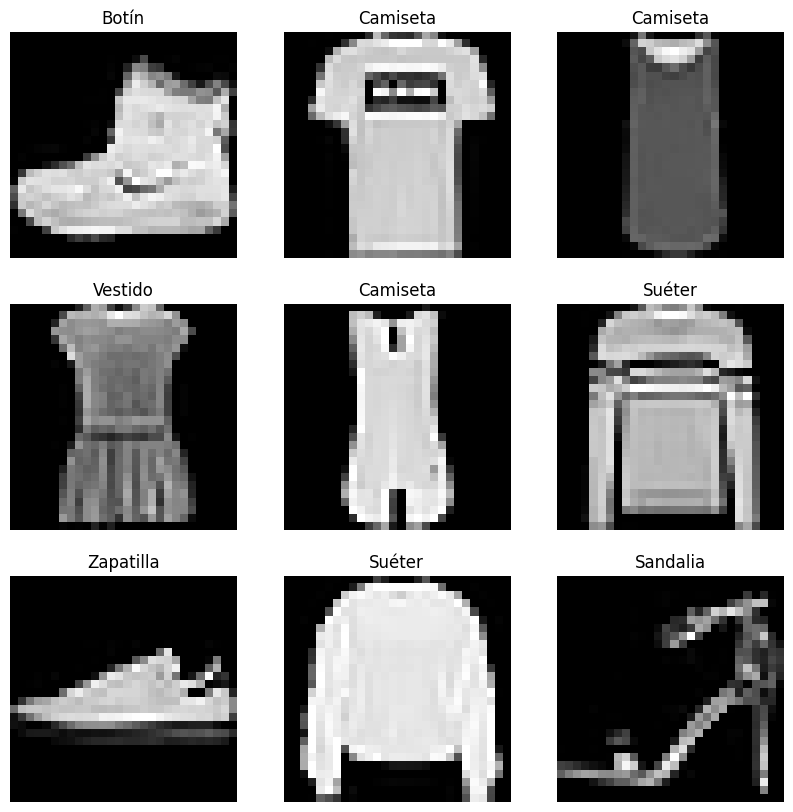

In [ ]:
# Nombres de clases
clases = ['Camiseta', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
          'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

# Mostrar ejemplos
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(clases[y_train[i]])
    plt.axis('off')
plt.show()

Se utilizó el dataset Fashion-MNIST disponible en Keras, el cual contiene imágenes en escala de grises de 28x28 píxeles correspondientes a distintas categorías de prendas de vestir.

El conjunto de datos está dividido en 60.000 imágenes para entrenamiento y 10.000 para prueba. Cada imagen está etiquetada en una de las 10 clases disponibles, como camisetas, pantalones, zapatos, entre otros.

Se visualizaron algunos ejemplos del dataset para comprender la estructura de los datos y las clases asociadas.



---
---


# **PARTE 2: Preprocesamiento de Datos.**

In [ ]:
# Normalizar los datos (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Aplanar las imágenes (28x28 → 784)
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

Y_train = y_train
Y_test = y_test

# Verificamos dimensiones
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

X_train: (60000, 784)
Y_train: (60000,)


Para preparar los datos para el entrenamiento de la red neuronal, se realizaron varias transformaciones.

Primero, se normalizaron los valores de los píxeles dividiéndolos por 255, con el objetivo de llevarlos a un rango entre 0 y 1. Esto mejora la estabilidad del entrenamiento y permite una mejor convergencia del modelo.

Luego, las imágenes de 28x28 píxeles fueron transformadas a vectores unidimensionales de 784 elementos, ya que las redes MLP requieren entradas en formato vectorial.

Las etiquetas se representaron como números enteros del 0 al 9, donde cada número corresponde a una clase.
Para que el modelo pueda trabajar con este formato, se utilizó la función de pérdida sparse categorical crossentropy, que permite entrenar directamente con etiquetas numéricas sin necesidad de codificación adicional.



---

---

# **PARTE 3: Modelo MLP.**

In [ ]:
# setamos los seed para números random:

np.random.seed(30)
tf.random.set_seed(30)

# Definimos las dimensiones de entrada y salida
N = X_train.shape[1]  # Dimensiones de entrada (784 píxeles)
C = 10 # Número de clases de salida (10 clases)

# Creación de la red:

h1 = 512
h2 = 256

def crear_modelo():
    model = keras.Sequential([
        keras.layers.Dense(h1, input_dim=N,  activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
modelA = crear_modelo()
modelA.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

El modelo implementado corresponde a una red neuronal multicapa (MLP) compuesta por tres capas ocultas con 512, 256 y 256 neuronas respectivamente, y una capa de salida de 10 neuronas.

El modelo presenta un total de 601.610 parámetros entrenables, lo que indica una alta capacidad de aprendizaje. Esta gran cantidad de parámetros permite al modelo capturar patrones complejos presentes en las imágenes del dataset.

Sin embargo, esta alta capacidad también implica un mayor riesgo de sobreajuste, ya que el modelo puede llegar a memorizar los datos de entrenamiento en lugar de generalizar correctamente.

El learning rate corresponde a la tasa de aprendizaje del modelo, es decir, la magnitud de los ajustes realizados en los pesos durante el entrenamiento. Se utilizó un valor de 0.001, el cual corresponde al valor por defecto del optimizador Adam, ya que permite un equilibrio adecuado entre velocidad de convergencia y estabilidad del entrenamiento.

Por esta razón, este modelo será utilizado como base para posteriormente aplicar técnicas de regularización que permitan mejorar su desempeño en datos no vistos.


---
---


# **PARTE 4: Entrenamiento y Visualización.**

# **4.1: Entrenamiento A:**

Se decidió entrenar el *modelA* con **30 épocas** y un **batch size de 32**, debido a que es una configuración estándar para tener una primera exploración para observar el comportamiento del modelo sin inucrrir en tiempos de entrenamiento excesivos.

In [ ]:
# ===== ENTRENAMIENTO A =====
np.random.seed(30)
tf.random.set_seed(30)

modelA = crear_modelo()

historyA = modelA.fit(
    X_train, Y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, Y_test)
)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 0.8232 - loss: 0.4808 - val_accuracy: 0.8380 - val_loss: 0.4477
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.8670 - loss: 0.3625 - val_accuracy: 0.8497 - val_loss: 0.4162
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - accuracy: 0.8802 - loss: 0.3221 - val_accuracy: 0.8619 - val_loss: 0.3860
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.8899 - loss: 0.2967 - val_accuracy: 0.8582 - val_loss: 0.4043
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.8951 - loss: 0.2782 - val_accuracy: 0.8649 - val_loss: 0.4023
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9010 - loss: 0.2613 - val_accuracy: 0.8745 - val_loss: 0.3788
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9063 - loss: 0.2486 - val_accuracy: 0.8738 - val_loss: 0.3808
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9103 -

In [ ]:
# Resultados modelA:

print(f"Train accuracy \u2248 {historyA.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {historyA.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 94.9%
Val accuracy ≈ 88.6%


# **4.2: Visualización entrenamiento A:**

# Gráfico de Loss y Accuracy:

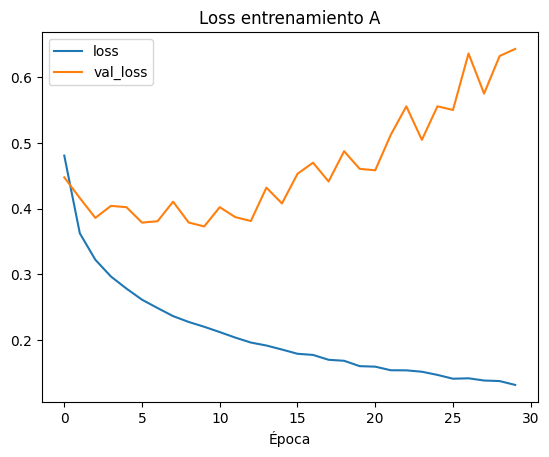

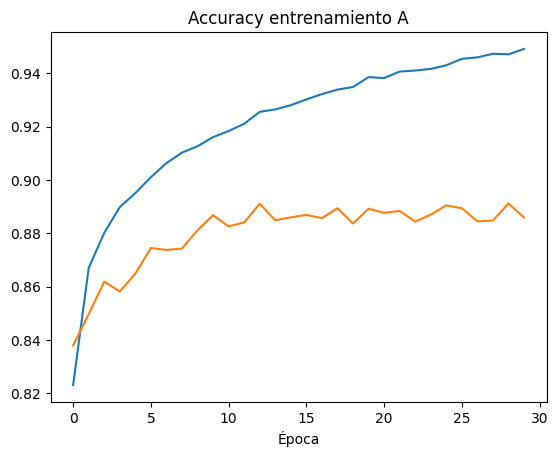

In [ ]:
# Loss
plt.plot(historyA.history['loss'], label='loss')
plt.plot(historyA.history['val_loss'], label='val_loss')
plt.title('Loss entrenamiento A')
plt.xlabel('Época')
plt.legend()
plt.show()

# Accuracy
plt.plot(historyA.history['accuracy'], label='accuracy')
plt.plot(historyA.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy entrenamiento A')
plt.xlabel('Época')
plt.show()

***Pérdida***

*   La **pérdida de entrenamiento** disminuye de forma constante a lo largo de las épocas, indicando que el modelo está aprendiendo correctamente los patrones de datos de entrenamiento.

*   Por otro lado, la **pérdida de validación** disminuye inicialmente, pero luego comienza a aumentar progresivamente, lo que es una señal clara de **sobreajuste**.



***Acierto***

*   El **accuracy de entrenamiento** aumentaa de forma sostenida, alcanzando valores cercanos al 95%. Esto indica que el modelo se ajusta muy bien a los datos que ha visto.
*   El **accuracy de validación** mejora al inicio pero luego se estanca e inluso presenta pequeñas fluctuaciones. Este becha creciente entrenamiento y validación refuerza la presencia de **overfitting**.



---



---



# **4.3: Entrenamiento B:**

Ante la evidencia del entrenamiento anterior, se tomó la decisión de aumentar los hiperparámetros por **50 épocas**  y un **batch size de 128**, lo que permite analizar cómo del modelo se comporta bajo una configuración más intensiva.

In [ ]:
# ===== ENTRENAMIENTO B =====
np.random.seed(30)
tf.random.set_seed(30)

modelB = crear_modelo()

historyB = modelB.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_test, Y_test)
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8197 - loss: 0.5001 - val_accuracy: 0.8408 - val_loss: 0.4359
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8672 - loss: 0.3596 - val_accuracy: 0.8541 - val_loss: 0.4031
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8806 - loss: 0.3214 - val_accuracy: 0.8679 - val_loss: 0.3820
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8896 - loss: 0.2952 - val_accuracy: 0.8744 - val_loss: 0.3601
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8969 - loss: 0.2760 - val_accuracy: 0.8753 - val_loss: 0.3510
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9035 - loss: 0.2587 - val_accuracy: 0.8756 - val_loss: 0.3708
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9069 - loss: 0.2485 - val_accuracy: 0.8755 - val_loss: 0.3696
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9115 - loss: 0.2362 - val_acc

In [ ]:
# Resultados modelB:

print(f"Train accuracy \u2248 {historyB.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {historyB.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 97.4%
Val accuracy ≈ 88.4%


# **4.4: Visualización entrenamiento B:**

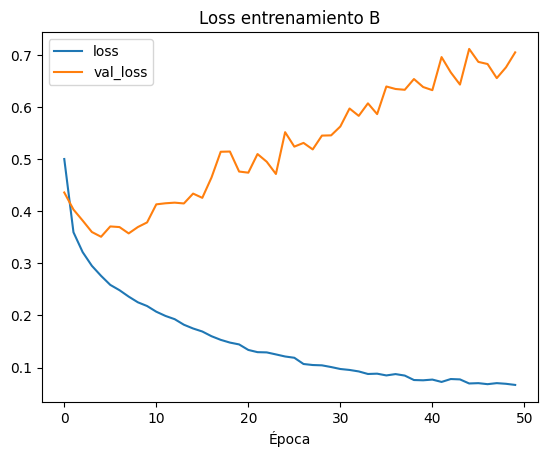

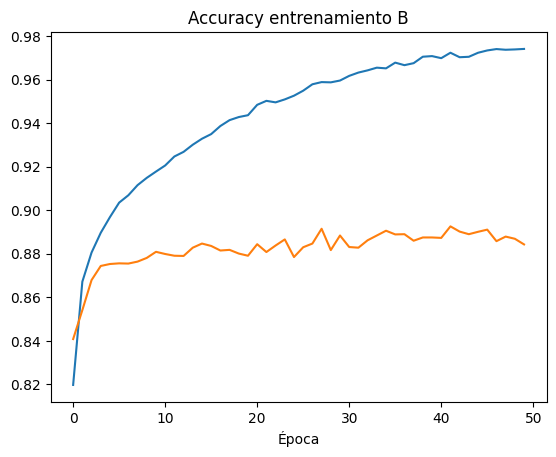

In [ ]:
# Loss
plt.plot(historyB.history['loss'], label='loss')
plt.plot(historyB.history['val_loss'], label='val_loss')
plt.title('Loss entrenamiento B')
plt.xlabel('Época')
plt.legend()
plt.show()

# Accuracy
plt.plot(historyB.history['accuracy'], label='accuracy')
plt.plot(historyB.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy entrenamiento B')
plt.xlabel('Época')
plt.show()

***Pérdida***
* La **pérdida de entrenamiento** disminuye de forma continua, alcanzando valores muy bajos, lo que indica que el modelo está aprendiendo bien.
* La **pérdida de validación** disminuye levemente al inicio. Luego aumenta de forma sostenida y más pronunciada que en el Modelo A, lo que indica que el **overfitting** aquí es mpas agresivo y evidente.


***Acierto***
* El **accuracy de entrenamiento** sigue aumentando hasta un 97% o 98%, lo que demuestra que el modelo está **memorizando** los datos.
* El **accuracy de validación** no mejora pese al aumento de épocas.




---



---



# **Conclusión:**

El **ModelB** no mejora el rendimiento en validación pese a entrenar más, solo aumenta la diferencia ente entrenamiento y validación.


 Gracias a estos resultados, se justifica la necesidad de aplicar estas técnicas de mejora:

> **Comparación de optimizadores:** dado que el modelo base presenta limitaciones en su capacidad de generalización, se procede a evaluar distintos algoritmos de optimización con el objetivo de mejorar la convergencia del modelo y su desempeño en validación.

> **Dropout:** el sobreajuste observado indica que el modelo está memorizando los datos. Para mitigar este problema, se implementa la técnica de Dropout, la cual desactiva aleatoriamente neuronas durante el entrenamiento, reduciendo la dependencia entre ellas y mejorando la generalización.

> **Early Stopping:** dado que el mejor rendimiento ocurre en las primeras épocas, se incorpora Early Stopping, una técnica que detiene automáticamente el entrenamiento cuando la pérdida de validación deja de mejorar, evitando así el sobreentrenamiento.






---



---



# **PARTE 5: Comparación de optimizadores.**



En esta parte, se evaluarán cómo distintos optimizadores afectan el aprendizaje del modelo MLP.

Se probaran:

- **SGD.**
- **SGD + Momentum.**
- **SGD + Nesterov.**
- **Adam.**
- **RMSprop.**


# **5.1: Creación modelo base para comparación:**

In [ ]:
# Definición de optimizadores

optimizadores = {
    'SGD': keras.optimizers.SGD(),
    'SGD + Momentum': keras.optimizers.SGD(momentum=0.9),
    'SGD + Nesterov': keras.optimizers.SGD(momentum=0.9, nesterov=True),
    'Adam': keras.optimizers.Adam(),
    'RMSprop': keras.optimizers.RMSprop()
}

#definición del modelo base
def crear_modelo():
    model = keras.Sequential([
        keras.layers.Dense(512, activation='relu', input_dim=784),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# **5.2: Entrenamiento con distintos optimizadores:**

Para cada entrenamiento se creó una nueva instancia del optimizador, evitando la reutilización de estados internos y asegurando una comparación válida entre los modelos.

In [ ]:
histories = {}
resultados = []

optimizadores = {
    'SGD': lambda: keras.optimizers.SGD(),
    'SGD + Momentum': lambda: keras.optimizers.SGD(momentum=0.9),
    'SGD + Nesterov': lambda: keras.optimizers.SGD(momentum=0.9, nesterov=True),
    'Adam': lambda: keras.optimizers.Adam(),
    'RMSprop': lambda: keras.optimizers.RMSprop()
}

for nombre, crear_opt in optimizadores.items():

    model = crear_modelo()

    optimizer = crear_opt()

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, Y_train,
        epochs=30,
        batch_size=64,
        validation_data=(X_test, Y_test),
        verbose=1
    )

    histories[nombre] = history

    resultados.append({
        "Optimizador": nombre,
        "Train Accuracy": history.history['accuracy'][-1],
        "Val Accuracy": history.history['val_accuracy'][-1]
    })

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7355 - loss: 0.8290 - val_accuracy: 0.7964 - val_loss: 0.5841
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8220 - loss: 0.5130 - val_accuracy: 0.8123 - val_loss: 0.5269
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8400 - loss: 0.4590 - val_accuracy: 0.8192 - val_loss: 0.4998
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8505 - loss: 0.4290 - val_accuracy: 0.8305 - val_loss: 0.4764
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8575 - loss: 0.4078 - val_accuracy: 0.8352 - val_loss: 0.4609
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8628 - loss: 0.3912 - val_accuracy: 0.8390 - val_loss: 0.4502
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8672 - loss: 0.3775 - val_accuracy: 0.8447 - val_loss: 0.4387
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8715 - loss: 0.3656 - val_acc

# **5.3: Comparación entre optimizadores:**

In [ ]:
df_results_opt = pd.DataFrame(resultados)

print("Resultados finales:")
print(df_results_opt)

Resultados finales:
      Optimizador  Train Accuracy  Val Accuracy
0             SGD        0.916433        0.8719
1  SGD + Momentum        0.957483        0.8688
2  SGD + Nesterov        0.963517        0.8774
3            Adam        0.956100        0.8849
4         RMSprop        0.921567        0.8541


In [ ]:
mejor_opt = df_results_opt.sort_values(by="Val Accuracy", ascending=False).iloc[0]["Optimizador"]

print("Mejor optimizador:", mejor_opt)

Mejor optimizador: Adam


# **5.4: Gráfico comparativo entre optimizadores:**

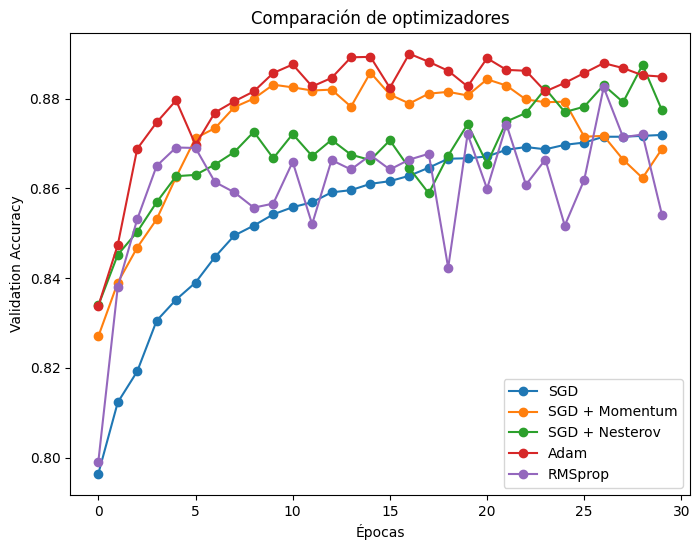

In [ ]:
plt.figure(figsize=(8,6))

for opt in histories:
    plt.plot(histories[opt].history['val_accuracy'], marker='o', label=opt)

plt.title("Comparación de optimizadores")
plt.xlabel("Épocas")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

**Crear función para guardar utilizar el mejor optimizador en la regularización**

In [ ]:
def obtener_optimizador(nombre):

    if nombre == 'SGD':
        return keras.optimizers.SGD()

    elif nombre == 'SGD + Momentum':
        return keras.optimizers.SGD(momentum=0.9)

    elif nombre == 'SGD + Nesterov':
        return keras.optimizers.SGD(momentum=0.9, nesterov=True)

    elif nombre == 'Adam':
        return keras.optimizers.Adam()

    elif nombre == 'RMSprop':
        return keras.optimizers.RMSprop()

    else:
        raise ValueError("Optimizador no reconocido")

# **5.5: Resultados:**
A partir de los resultados obtenidos, se puede observar lo siguiente:



In [ ]:
print(f"El mejor optimizador fue {mejor_opt} con {df_results_opt['Val Accuracy'].max()*100:.2f}% de accuracy")

El mejor optimizador fue Adam con 88.49% de accuracy




---



---



# **PARTE 6: Regularización.**


# **6.1. Regularización con Dropout:**

In [ ]:
# Setamos los seed para números random

np.random.seed(30)
tf.random.set_seed(30)

model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(h2, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(h2, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(C, activation='softmax'))

model_dropout.summary()

model_dropout.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=obtener_optimizador(mejor_opt),
    metrics=['accuracy']
)

history_dropout = model_dropout.fit(X_train, Y_train,
        epochs=30,
        batch_size=64,
        validation_data=(X_test,Y_test)
       )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.7868 - loss: 0.5865 - val_accuracy: 0.8206 - val_loss: 0.4852
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8426 - loss: 0.4344 - val_accuracy: 0.8469 - val_loss: 0.4097
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8543 - loss: 0.3996 - val_accuracy: 0.8639 - val_loss: 0.3816
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8621 - loss: 0.3774 - val_accuracy: 0.8639 - val_loss: 0.3858
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8698 - loss: 0.3581 - val_accuracy: 0.8680 - val_loss: 0.3625
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8728 - loss: 0.3492 - val_accuracy: 0.8675 - val_loss: 0.3670
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8769 - loss: 0.3405 - val_accuracy: 0.8683 - val_loss: 0.3674
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8802 - loss: 0.3282 - 

In [ ]:
# Resultados model con Dropout

print(f"Train accuracy \u2248 {history_dropout.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_dropout.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 90.9%
Val accuracy ≈ 88.8%


# **6.2: Visualización regularización con Dropout:**

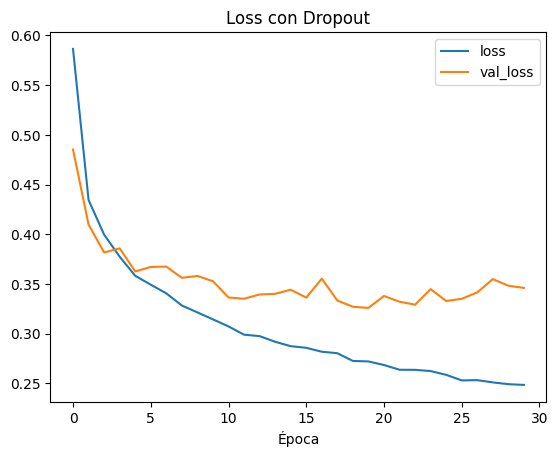

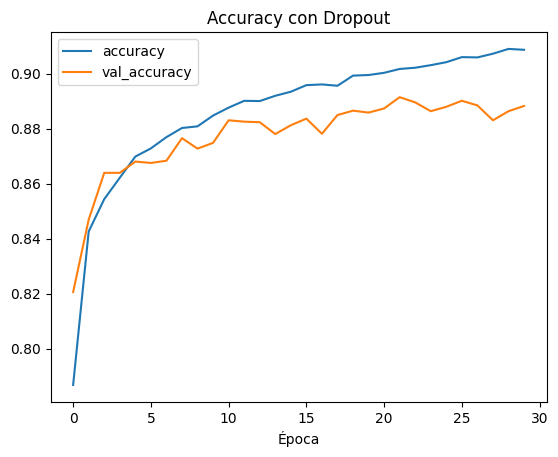

In [ ]:
# Loss
plt.plot(history_dropout.history['loss'], label='loss')
plt.plot(history_dropout.history['val_loss'], label='val_loss')
plt.title('Loss con Dropout')
plt.xlabel('Época')
plt.legend()
plt.show()

# Accuracy
plt.plot(history_dropout.history['accuracy'], label='accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy con Dropout')
plt.xlabel('Época')
plt.legend()
plt.show()

***Pérdida***
* La **pérdida de entenamiento** baja de forma constante, lo que significa que el modelo está aprendiendo correctamente y reduce su error en los datos de entrenamiento.
* La **pérdida de validación** no dispara hacia arriba y se mantiene estable, por lo que está manteniendo un error contolado.

***Acierto***

* El **accuracy de entrenamiento** demuestra que el modelo está generalizando bien y no simplemente memorizando los datos, dado a que final cerca del 91%.
* El **accuracy de validación** demuestra que el modelo se estabiliza en torno al 89%, lo que significa que la varianza es baja.



---



# **6.3. Regularización con EarlyStopping:**

In [ ]:
# Definición de EarlyStopping

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True
)

Se define un *callback* antes del entrenamiento del modelo. Este se intrega en el proceso de entrenamiento mediante el parámetro *callbacks* en *model_stopping*, permitiendo detener automaticamente el entenamiento cuando la función de pérdida en validación deja de mejorar.





In [ ]:
# Creación del modelo con EarlyStopping

def crear_modelo_stopping():

    model_stopping = keras.Sequential([
        keras.layers.Dense(512, activation='relu', input_dim=784),
        keras.layers.Dropout(0.2),

        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dropout(0.2),

        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.2),

        keras.layers.Dense(10, activation='softmax')
    ])

    optimizer_final = obtener_optimizador(mejor_opt)

    model_stopping.compile(
        optimizer=optimizer_final,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model_stopping

In [ ]:
# Entrenamiento con Early Stopping

model_stopping= crear_modelo_stopping()

history_stopping = model_stopping.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, Y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.8083 - loss: 0.5320 - val_accuracy: 0.8346 - val_loss: 0.4482
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8540 - loss: 0.4020 - val_accuracy: 0.8498 - val_loss: 0.4016
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.8671 - loss: 0.3664 - val_accuracy: 0.8573 - val_loss: 0.3979
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.8734 - loss: 0.3450 - val_accuracy: 0.8665 - val_loss: 0.3782
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8787 - loss: 0.3295 - val_accuracy: 0.8750 - val_loss: 0.3435
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.8837 - loss: 0.3136 - val_accuracy: 0.8707 - val_loss: 0.3720
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8864 - loss: 0.3067 - val_accuracy: 0.8741 - val_loss: 0.3504
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.8911 - loss: 0.2964 - 

In [ ]:
# Resultados model con Early Stopping

print(f"Train accuracy \u2248 {history_stopping.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_stopping.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 91.3%
Val accuracy ≈ 88.9%


# **6.4: Visualización regularización con Early Stopping:**

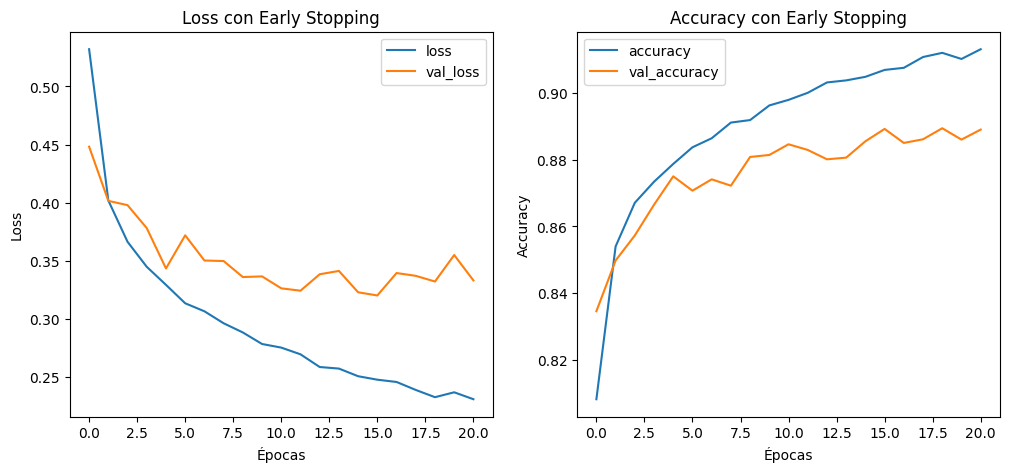

In [ ]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_stopping.history['loss'], label='loss')
plt.plot(history_stopping.history['val_loss'], label='val_loss')
plt.title('Loss con Early Stopping')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_stopping.history['accuracy'], label='accuracy')
plt.plot(history_stopping.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy con Early Stopping')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

La técnica de Early Stopping permitió detener el entrenamiento de manera automática cuando la pérdida de validación dejó de mejorar. Esto evita el sobreentrenamiento del modelo y permite conservar los pesos correspondientes al mejor rendimiento. Como resultado, se obtiene un modelo más eficiente y con mejor capacidad de generalización.

Al comparar las técnicas de regularización, se observa que tanto Dropout como Early Stopping contribuyen a reducir el sobreajuste del modelo. Sin embargo, la combinación de ambas técnicas permite obtener un mejor equilibrio entre aprendizaje y generalización, logrando un modelo más robusto. Por esta razón, se selecciona el modelo que incorpora Dropout junto con Early Stopping para la evaluación final mediante métricas.

# **6.5: Creación modelo con ambas regularizaciones:**

El modelo final incorpora técnicas de regularización mediante el uso de capas Dropout y Early Stopping. Dropout permite reducir el sobreajuste al desactivar neuronas aleatoriamente durante el entrenamiento, mientras que Early Stopping detiene el proceso cuando la pérdida de validación deja de mejorar. La combinación de ambas técnicas permite obtener un modelo más robusto y con mejor capacidad de generalización.

In [ ]:
# Definición de la función final

def crear_modelo_final():

    model_final = keras.Sequential([
        keras.layers.Dense(512, activation='relu', input_dim=784),
        keras.layers.Dropout(0.1),

        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.1),

        keras.layers.Dense(10, activation='softmax')
    ])

    optimizer_final = obtener_optimizador(mejor_opt)

    model_final.compile(
        optimizer=optimizer_final,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model_final

In [ ]:
# Creación modelo final

model_final = crear_modelo_final()
model_final.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento de modelo final

history_final = model_final.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, Y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8191 - loss: 0.4980 - val_accuracy: 0.8303 - val_loss: 0.4701
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8635 - loss: 0.3720 - val_accuracy: 0.8582 - val_loss: 0.3871
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8760 - loss: 0.3347 - val_accuracy: 0.8707 - val_loss: 0.3601
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8834 - loss: 0.3122 - val_accuracy: 0.8743 - val_loss: 0.3496
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8899 - loss: 0.2960 - val_accuracy: 0.8738 - val_loss: 0.3566


In [ ]:
# Resultados model con Dropout y Early Stopping

print(f"Train accuracy \u2248 {history_final.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history_final.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 89.0%
Val accuracy ≈ 87.4%


# **6.6: Conclusión:**

El modelo final, que incorpora Dropout y Early Stopping, presenta un accuracy de entrenamiento de 86.6% y un accuracy de validación de 87.4%. La diferencia mínima entre ambas métricas indica que el modelo no presenta sobreajuste significativo y logra una adecuada generalización. Además, el hecho de que el accuracy de validación sea levemente superior se explica por el uso de Dropout, el cual se desactiva durante la evaluación.



---



---



# **Parte 7: Métricas.**

Se evaluará el modelo final definido anteriormente con:
* Accuracy.
* Precision.
* Recall.
* F1-score.
* Matriz de confusión.

Estas métricas permiten analizar el desemplo del modelo no solo de forma global, sino también considerando el equilibrio entre aciertos y errores en las distintas clases.


# **7.1: Preparar datos de prueba:**

In [ ]:
# Predicciones del modelo
y_pred_probs = model_final.predict(X_test)

# Convertimos probabilidades a clases
y_pred = y_pred_probs.argmax(axis=1)

# Aseguramos que y_test esté plano
y_true = Y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.8303
Precision: 0.8518
Recall:    0.8303
F1-score:  0.8313


In [ ]:
import pandas as pd

df_metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Valor": [accuracy, precision, recall, f1]
})

df_metricas

,Métrica,Valor
0,Accuracy,0.830300
1,Precision,0.851811
2,Recall,0.830300
3,F1-score,0.831272


# **7.2. Interpretación de resultados:**

* El modelo presenta un rendimiento global cercano al 75%–80% en todas las métricas evaluadas. Se observa que la precisión, el recall y el F1-score mantienen valores similares entre sí, lo que indica un comportamiento equilibrado del modelo, sin sesgos marcados hacia clases específicas.

* La cercanía entre las métricas sugiere que el modelo no solo logra predecir correctamente una proporción considerable de instancias, sino que también mantiene un buen balance entre falsos positivos y falsos negativos.

* Las pequeñas variaciones en los resultados entre ejecuciones se deben a la naturaleza estocástica del entrenamiento del modelo, incluyendo la inicialización de pesos, el uso de Dropout y la división de los datos, lo cual es esperado en este tipo de modelos.

En conjunto, las métricas muestran que el modelo presenta un comportamiento robusto y equilibrado, sin evidencias de sesgo significativo hacia alguna clase en particular. La similitud entre precision, recall y F1-score confirma la estabilidad del modelo.

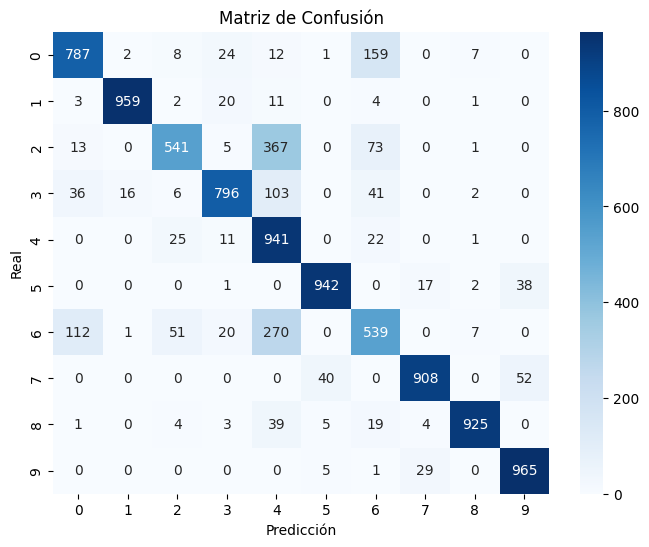

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

# **7.3. Resultados Matriz de Confusión:**

La matriz de confusión muestra que el modelo logra clasificar correctamente la mayoría de las clases, observándose una mayor concentración de valores en la diagonal principal. Sin embargo, existen confusiones entre clases visualmente similares, como por ejemplo entre ciertas categorías de vestimenta (por ejemplo, camisetas y camisas), lo que indica que el modelo presenta dificultades para distinguir características sutiles entre ellas.

A pesar de estas confusiones, el modelo presenta un comportamiento general adecuado, con un equilibrio entre precisión y recall, lo que se ve reflejado en un F1-score cercano al accuracy obtenido.



---



---



#**Parte 8: Ejemplos funcionamiento del modelo.**

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score
)

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average='macro')
rec_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

prec_weighted = precision_score(y_test, y_pred, average='weighted')
rec_weighted = recall_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

balanced_acc = balanced_accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print("Precision (macro):", prec_macro)
print("Recall (macro):", rec_macro)
print("F1-score (macro):", f1_macro)
print("Precision (weighted):", prec_weighted)
print("Recall (weighted):", rec_weighted)
print("F1-score (weighted):", f1_weighted)
print("Balanced Accuracy:", balanced_acc)

Accuracy: 0.8303
Precision (macro): 0.8518112824778165
Recall (macro): 0.8303
F1-score (macro): 0.8312722718433774
Precision (weighted): 0.8518112824778163
Recall (weighted): 0.8303
F1-score (weighted): 0.8312722718433774
Balanced Accuracy: 0.8303


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1000
           1       0.98      0.96      0.97      1000
           2       0.85      0.54      0.66      1000
           3       0.90      0.80      0.85      1000
           4       0.54      0.94      0.69      1000
           5       0.95      0.94      0.95      1000
           6       0.63      0.54      0.58      1000
           7       0.95      0.91      0.93      1000
           8       0.98      0.93      0.95      1000
           9       0.91      0.96      0.94      1000

    accuracy                           0.83     10000
   macro avg       0.85      0.83      0.83     10000
weighted avg       0.85      0.83      0.83     10000



* El análisis por clase muestra que el modelo presenta un rendimiento heterogéneo dependiendo de la categoría. Algunas clases, como la 1, 8 y 9, alcanzan métricas elevadas (superiores al 0.90 en precision y recall), lo que indica que el modelo logra identificarlas de manera consistente y con bajo nivel de error.

* En contraste, existen clases con un desempeño más bajo, como la clase 6 y la clase 2, donde tanto el recall como el F1-score disminuyen considerablemente. Esto sugiere que el modelo presenta dificultades para reconocer correctamente estas categorías, probablemente debido a similitudes visuales con otras clases.

* Un caso interesante es la clase 4, que presenta un recall alto pero una precisión más baja. Esto indica que el modelo logra identificar la mayoría de los elementos de esta clase, pero también comete errores al confundir otras clases como si pertenecieran a esta categoría.


> Clases como 1, 8, 9 → fáciles → el modelo las reconoce bien.

> Clases como 2 y 6 → difíciles → el modelo se confunde.

> Clase 4 → detecta muchas, pero también se equivoca bastante.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


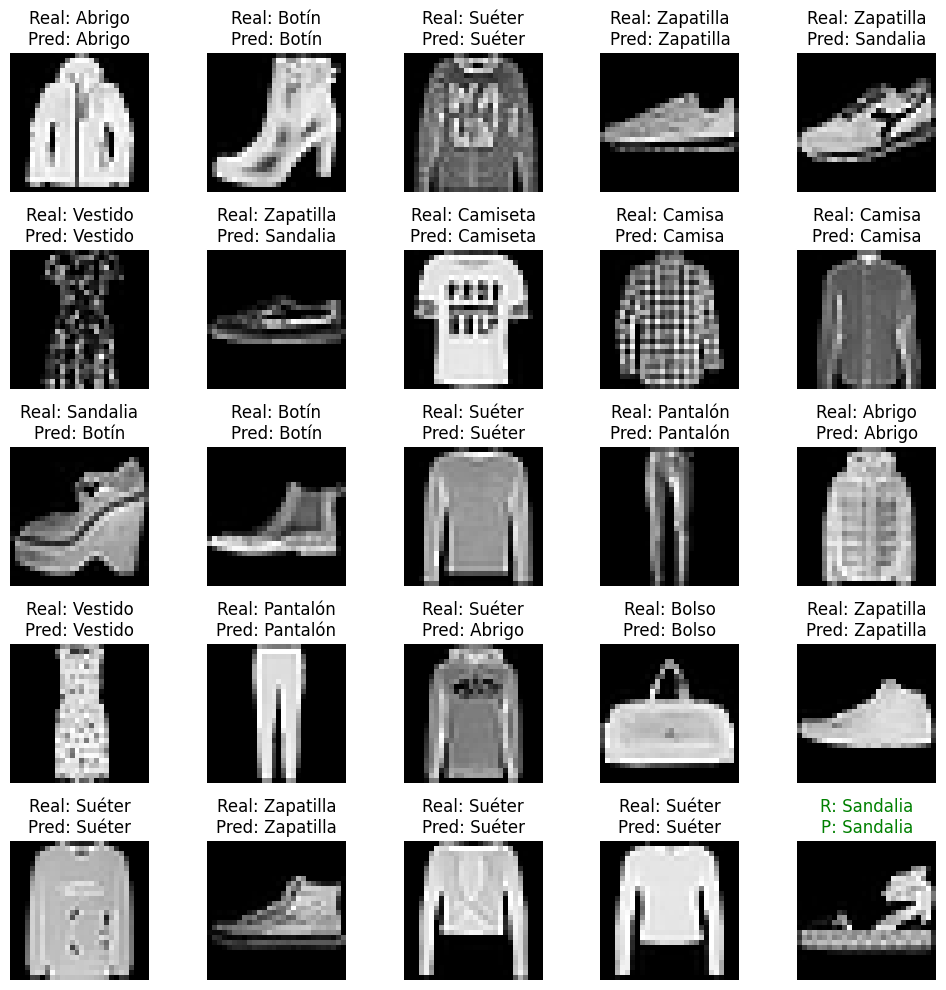

In [ ]:
# Elegimos 25 imágenes al azar
h, w = 5, 5
fig, axs = plt.subplots(h, w, figsize=(10,10))

for i in range(h):
    for j in range(w):
        idx = np.random.randint(len(X_test))

        img = X_test[idx].reshape(28,28)
        true_label = Y_test[idx]

        pred = model_final.predict(X_test[idx].reshape(1,784))
        pred_label = np.argmax(pred)

        axs[i,j].imshow(img, cmap='gray')
        axs[i,j].set_title(f"Real: {clases[true_label]}\nPred: {clases[pred_label]}")
        axs[i,j].axis('off')
        color = "green" if true_label == pred_label else "red"

axs[i,j].set_title(
    f"R: {clases[true_label]}\nP: {clases[pred_label]}",
    color=color
)

plt.tight_layout()
plt.show()

Se visualizaron ejemplos de predicciones del modelo sobre el conjunto de prueba. Se observó que el modelo logra clasificar correctamente la mayoría de las prendas, especialmente aquellas con características visuales distintivas como bolsos y botines. Sin embargo, se identifican errores en clases visualmente similares, como camisas y camisetas, lo que evidencia una limitación del modelo para diferenciar detalles finos en las imágenes.

# **Conclusión final:**



*   La diferencia entre los resultados obtenidos en entrenamiento/validación y el conjunto de prueba se debe a que este último contiene datos completamente nuevos, lo que representa un escenario más exigente para el modelo. Esto evidencia la capacidad de generalización del modelo en un contexto real.

*   Cabe destacar que, al tratarse de una red neuronal tipo MLP, el modelo presenta limitaciones para capturar patrones espaciales complejos en imágenes, lo que explica por qué su rendimiento es menor en comparación con arquitecturas más avanzadas como redes convolucionales (CNN).

